In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
df = pd.read_csv('../dados/taylor_swift_limpo.csv')

In [12]:
df.head()

,track_name,duration_ms,explicit,album_name,danceability,energy,loudness,speechiness,acousticness,instrumentalness,liveness,valence
0,Fortnight (feat. Post Malone),228965,False,THE TORTURED POETS DEPARTMENT: THE ANTHOLOGY,0.504,0.386,-10.976,0.0308,0.5020,0.000015,0.0961,0.281
1,The Tortured Poets Department,293048,True,THE TORTURED POETS DEPARTMENT: THE ANTHOLOGY,0.604,0.428,-8.441,0.0255,0.0483,0.000000,0.1260,0.292
2,My Boy Only Breaks His Favorite Toys,203801,False,THE TORTURED POETS DEPARTMENT: THE ANTHOLOGY,0.596,0.563,-7.362,0.0269,0.1370,0.000000,0.3020,0.481
3,Down Bad,261228,True,THE TORTURED POETS DEPARTMENT: THE ANTHOLOGY,0.541,0.366,-10.412,0.0748,0.5600,0.000001,0.0946,0.168
4,"So Long, London",262974,False,THE TORTURED POETS DEPARTMENT: THE ANTHOLOGY,0.423,0.533,-11.388,0.3220,0.7300,0.002640,0.0816,0.248


In [13]:
le = LabelEncoder()
X = df.drop(columns=['album_name','track_name', 'instrumentalness'])
Y = le.fit_transform(df['album_name'])
X_train, X_test, Y_train, Y_test = train_test_split(X,Y,test_size=0.25,random_state=42, stratify=Y)

In [14]:
rf_model = RandomForestClassifier(n_estimators=100, random_state=42, max_depth=None, n_jobs=-1)
rf_model.fit(X_train, Y_train)
y_pred = rf_model.predict(X_test)


In [15]:
print(f"🎯 Acurácia Geral: {accuracy_score(Y_test, y_pred):.2%}\n")
print("--- RELATÓRIO DE CLASSIFICAÇÃO ---")
print(classification_report(Y_test, y_pred))

🎯 Acurácia Geral: 32.76%

--- RELATÓRIO DE CLASSIFICAÇÃO ---
              precision    recall  f1-score   support

           0       0.29      0.40      0.33         5
           1       0.00      0.00      0.00         7
           2       0.00      0.00      0.00         5
           3       0.43      0.50      0.46         6
           4       0.30      0.43      0.35         7
           5       0.50      0.40      0.44         5
           6       0.36      0.50      0.42         8
           7       0.50      0.67      0.57         3
           8       0.67      0.50      0.57         4
           9       0.00      0.00      0.00         4
          10       0.25      0.25      0.25         4

    accuracy                           0.33        58
   macro avg       0.30      0.33      0.31        58
weighted avg       0.29      0.33      0.30        58



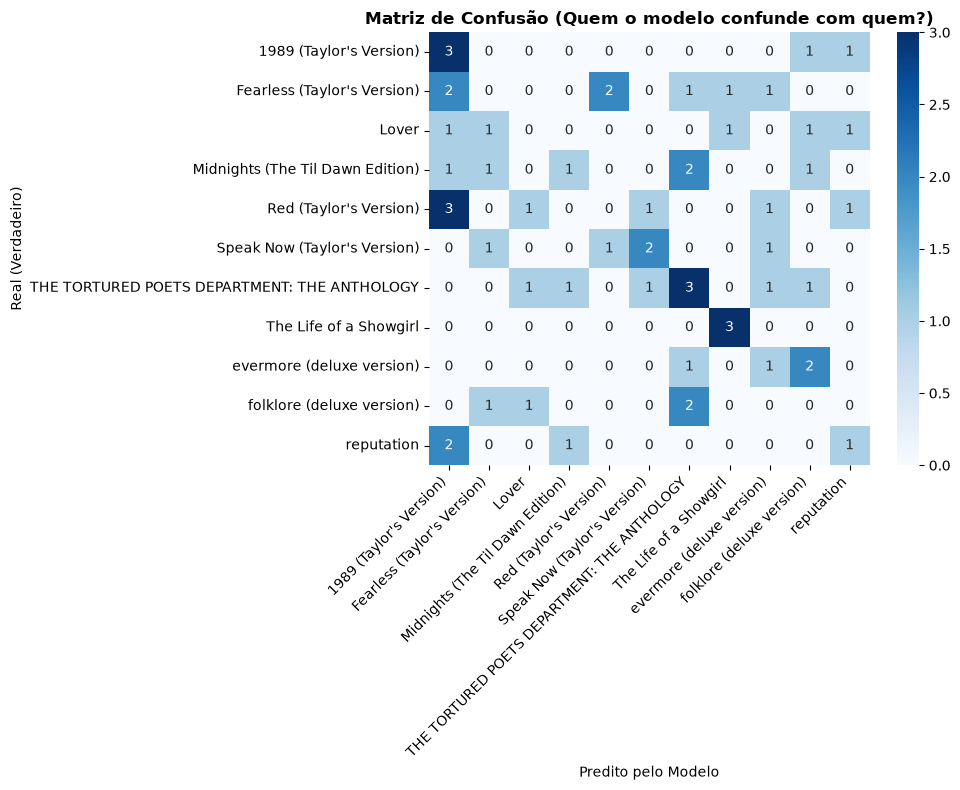

In [17]:
# 1. Random Forest com pesos balanceados
rf_balanced = RandomForestClassifier(
    n_estimators=200, 
    max_depth=8,              # Evita overfitting no treino
    class_weight='balanced',   # Dá mais peso para classes difíceis
    random_state=42, 
    n_jobs=-1
)
rf_balanced.fit(X_train, Y_train)
y_pred_bal = rf_balanced.predict(X_test)

# 2. Matriz de Confusão Visual
plt.figure(figsize=(10, 8))
cm = confusion_matrix(Y_test, y_pred_bal)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=le.classes_, yticklabels=le.classes_)
plt.title('Matriz de Confusão (Quem o modelo confunde com quem?)', fontweight='bold')
plt.xlabel('Predito pelo Modelo')
plt.ylabel('Real (Verdadeiro)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()